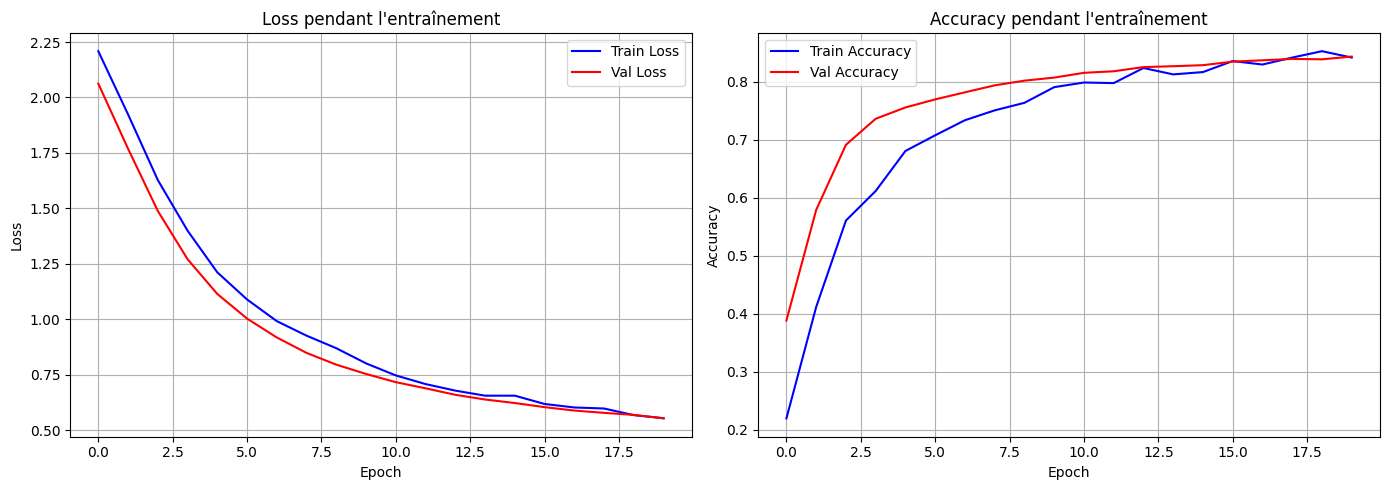

Model saved in ts_simple_network_test_trained.h5


In [1]:
# En haut de la cellule
%matplotlib inline

from keras.datasets import mnist
import sys
import numpy as np
sys.path.append('game/')
from ts_simple_neural_network import TsSimpleNeuralNetwork

import matplotlib.pyplot as plt
from IPython.display import clear_output
from tensorflow.keras.callbacks import Callback

class LivePlotCallback(Callback):
    def __init__(self):
        self.epochs = []
        self.loss = []
        self.val_loss = []
        self.acc = []
        self.val_acc = []
        
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.epochs.append(epoch)
        self.loss.append(logs.get('loss'))
        self.val_loss.append(logs.get('val_loss'))
        self.acc.append(logs.get('accuracy'))
        self.val_acc.append(logs.get('val_accuracy'))
        
        # Effacer et redessiner
        clear_output(wait=True)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Loss
        ax1.plot(self.epochs, self.loss, 'b-', label='Train Loss')
        ax1.plot(self.epochs, self.val_loss, 'r-', label='Val Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('Loss pendant l\'entraînement')
        ax1.legend()
        ax1.grid(True)
        
        # Accuracy
        ax2.plot(self.epochs, self.acc, 'b-', label='Train Accuracy')
        ax2.plot(self.epochs, self.val_acc, 'r-', label='Val Accuracy')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.set_title('Accuracy pendant l\'entraînement')
        ax2.legend()
        ax2.grid(True)
        
        plt.tight_layout()
        plt.show()

# Chargement des données
(x_train, y_train), (x_test, y_test) = mnist.load_data()
images, labels = (x_train[0:1000].reshape(1000, 28*28) / 255, y_train[0:1000])
test_images = x_test.reshape(len(x_test), 28*28) / 255
test_labels = np.zeros((len(y_test), 10))

one_hot_labels = np.zeros((len(labels), 10))
for i, l in enumerate(labels):
    one_hot_labels[i][l] = 1
labels = one_hot_labels

for i, l in enumerate(y_test):
    test_labels[i][l] = 1

# Création du réseau
nn = TsSimpleNeuralNetwork(
    input_shape=(28*28,),
    layer_sizes=[40, 10],
    activation_functions=['relu', 'softmax'],
    with_dropout=True,
    loss_fct='categorical_crossentropy',
    metrics=['accuracy']
)

# Entraînement avec visualisation
live_plot = LivePlotCallback()
history = nn.train(
    inputs=images,
    labels=labels,
    test_inputs=test_images,
    test_labels=test_labels,
    iterations=20,
    verbose=0,  # Mettre à 0 pour ne pas polluer la sortie
    callbacks=[live_plot]
)

nn.save(file_path="ts_simple_network_test_trained.h5")

Model loaded from ts_simple_network_test_trained.h5


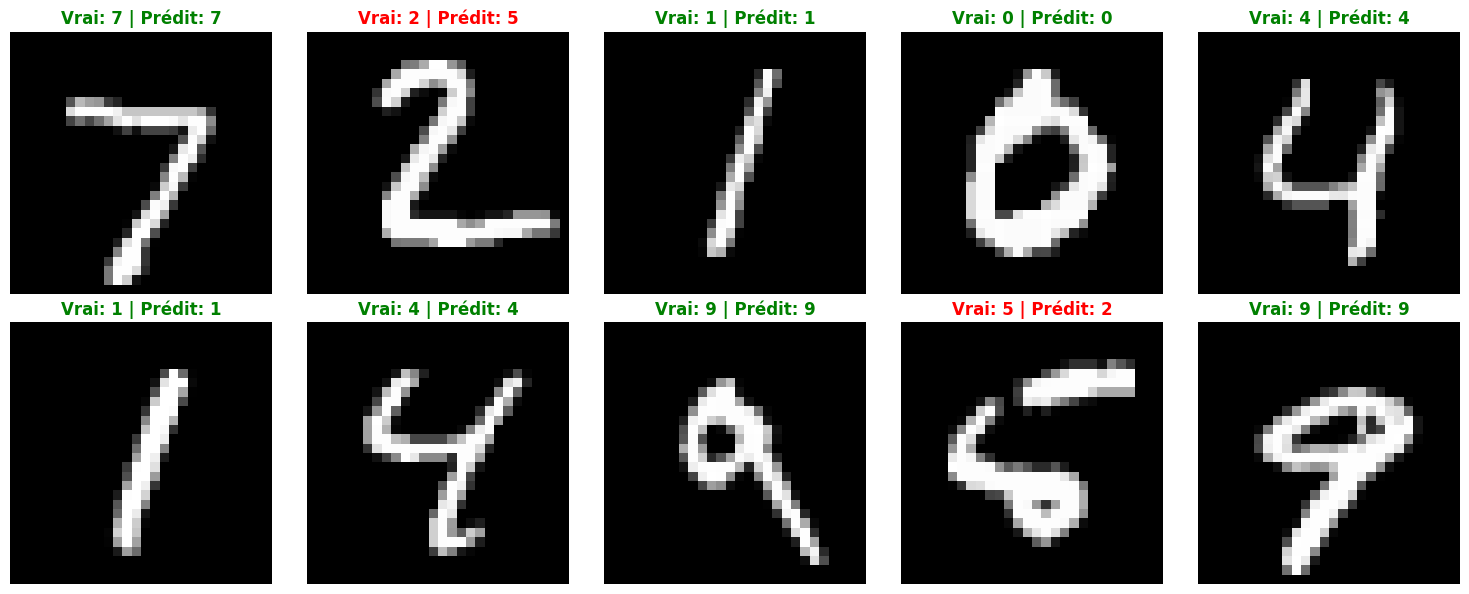


📊 Détails des prédictions :
------------------------------------------------------------
✅ Image 0: Vrai=7 | Prédit=7 | Confiance=96.3%
❌ Image 1: Vrai=2 | Prédit=5 | Confiance=32.2%
✅ Image 2: Vrai=1 | Prédit=1 | Confiance=80.2%
✅ Image 3: Vrai=0 | Prédit=0 | Confiance=97.4%
✅ Image 4: Vrai=4 | Prédit=4 | Confiance=77.1%
✅ Image 5: Vrai=1 | Prédit=1 | Confiance=88.4%
✅ Image 6: Vrai=4 | Prédit=4 | Confiance=52.9%
✅ Image 7: Vrai=9 | Prédit=9 | Confiance=60.0%
❌ Image 8: Vrai=5 | Prédit=2 | Confiance=44.9%
✅ Image 9: Vrai=9 | Prédit=9 | Confiance=50.0%


In [5]:
import matplotlib.pyplot as plt

# Charger le modèle
nn.load(file_path="ts_simple_network_test_trained.h5")

# Créer une figure avec 2 lignes et 5 colonnes
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    image = test_images[i]
    true_label = np.argmax(test_labels[i])  # Convertir one-hot vers classe
    
    # Prédiction (il faut reshape pour ajouter la dimension batch)
    prediction = nn.forward(image.reshape(1, -1))
    predicted_label = np.argmax(prediction)
    
    # Afficher l'image
    axes[i].imshow(image.reshape(28, 28), cmap='gray')
    
    # Couleur du titre : vert si correct, rouge si incorrect
    color = 'green' if predicted_label == true_label else 'red'
    axes[i].set_title(f'Vrai: {true_label} | Prédit: {predicted_label}', 
                      color=color, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Afficher les détails pour les premières images
print("\n📊 Détails des prédictions :")
print("-" * 60)
for i in range(10):
    image = test_images[i]
    true_label = np.argmax(test_labels[i])
    
    prediction = nn.forward(image.reshape(1, -1))
    predicted_label = np.argmax(prediction)
    confidence = np.max(prediction) * 100
    
    status = "✅" if predicted_label == true_label else "❌"
    print(f"{status} Image {i}: Vrai={true_label} | Prédit={predicted_label} | Confiance={confidence:.1f}%")